In [1]:
import pandas as pd
from scipy.spatial.transform import Rotation as R

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import plot_embedding

# UMAP uncertainty
Evaluated by comparing how similar various UMAP runs are. Since they may be mirrored, rotated and/or translated, a semi-automatic procedure first tries to map the embeddings onto each other.

Since 100 UMAP embeddings were already computed for UMAP-DBSCAN uncertainty experiments, those files are used and loaded instead of computing new embeddings.

In [2]:
def rotate_umap(u, x, y, z, factor=1):
    """ Rotating the embedding around x, y and z axis. """
    rx = R.from_euler('x', x, degrees=True)
    ry = R.from_euler('y', y, degrees=True)
    rz = R.from_euler('z', z, degrees=True)
    factor = float(factor)
    u_r = rx.apply(ry.apply(rz.apply(factor*u)))
    return u_r

def get_user_input(u):
    """ Ask user whether to rotate the embedding. """
    plot_embedding(u, figsize=(4, 4))
    user_input = input("Rotate? y/n")
    if user_input == "y": 
        print("  y")
        rotx = input("x rotation: ")
        roty = input("y rotation: ")
        rotz = input("z rotation: ")
        fact = input("factor: ")
        umap_temp = rotate_umap(u, rotx, roty, rotz, factor=fact)
        return get_user_input(umap_temp)
    elif user_input == "n": 
        print("  n")
        return u
    else: 
        print("  repeating...")
        get_user_input(u)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


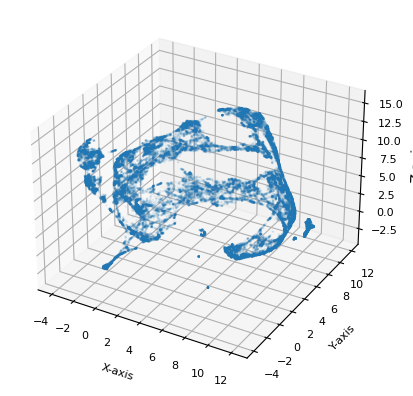

Rotate? y/n y


  y


x rotation:  0
y rotation:  0
z rotation:  0
factor:  -1


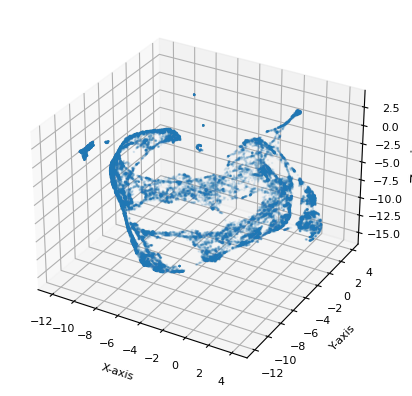

Rotate? y/n y


  y


x rotation:  0
y rotation:  0
z rotation:  90
factor:  1


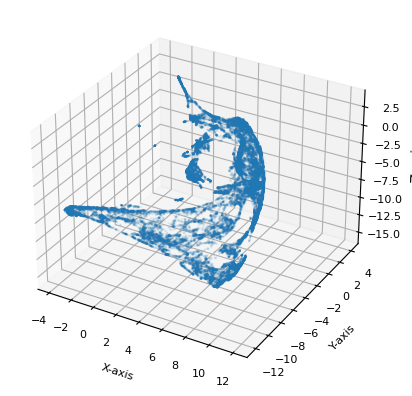

Rotate? y/n y


  y


x rotation:  0
y rotation:  0
z rotation:  90
factor:  1


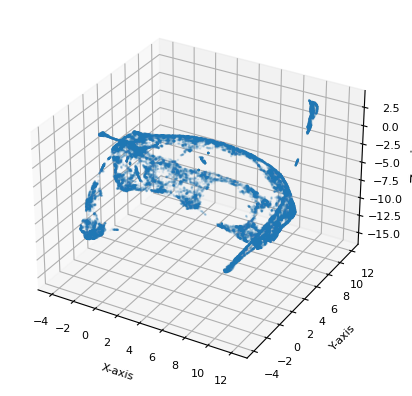

Rotate? y/n n


  n
22


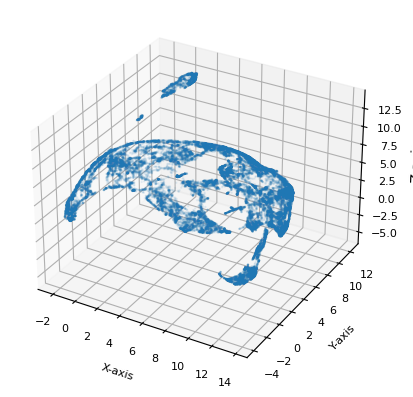

Rotate? y/n y


  y


x rotation:  90
y rotation:  0
z rotation:  0
factor:  1


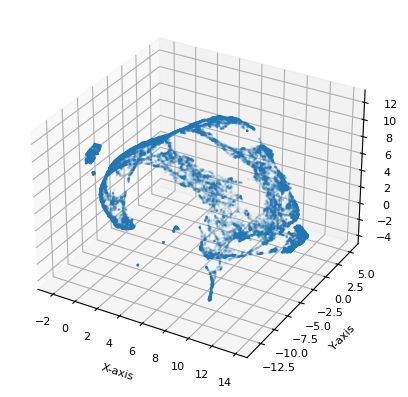

Rotate? y/n y


  y


x rotation:  90
y rotation:  0
z rotation:  0
factor:  1


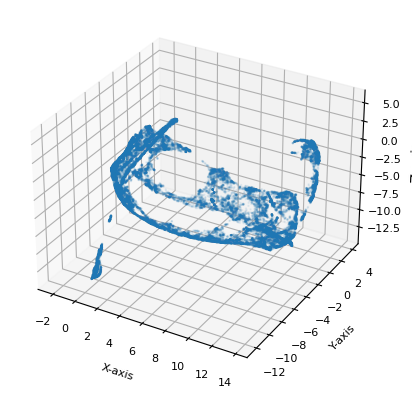

Rotate? y/n y


  y


x rotation:  0
y rotation:  0
z rotation:  0
factor:  -1


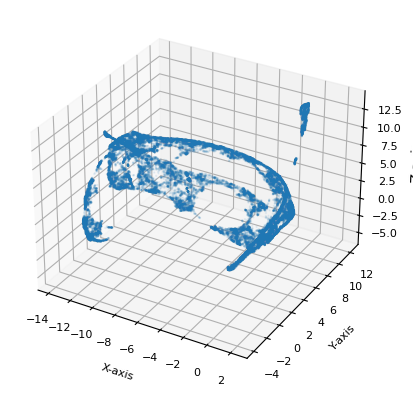

Rotate? y/n n


  n
23


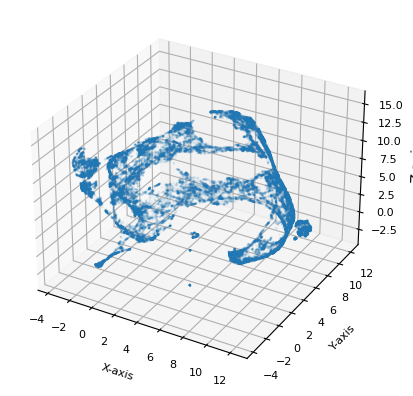

Rotate? y/n n


  n
24


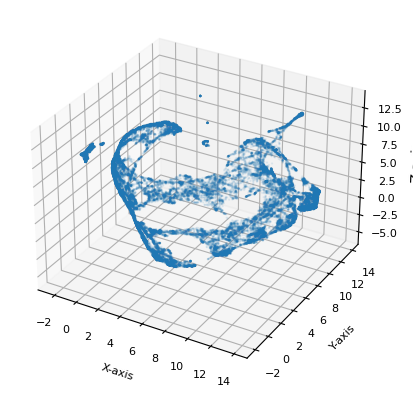

KeyboardInterrupt: Interrupted by user

In [27]:
# Manual rotation + mirroring 
umap_cols = [f"e{i}" for i in range(hyp_config.umap_hyps["n_components"])]

for i in range(config.n_iterations_uncertainty):
    print(i)
    if i > 22:
        filename = f"{config.output_dir_uncertainty}umap_dbscan_{i}.csv"
        df = pd.read_csv(filename)
    
        # Manual rotation + mirroring 
        umap_new = get_user_input(df[umap_cols].to_numpy())
    
        # Store new result (this will not change overlap since overlap was computed using space-time coordinates, not UMAP coordinates)
        df[umap_cols] = umap_new
        df.to_csv(filename, index=False)

In [ ]:
# load umaps and inspect visually
umaps = []
for p in glob(output_dir + "runs/umap_*.txt"):
    temp = np.loadtxt(p, dtype=float)
    umaps.append(temp)
    utils.plot_embedding(temp)

In [ ]:
# Automatic rotation
out = pd.DataFrame(columns=["no_icp_diff", "diff", "i", "j"])

for i in tqdm(range(num_iterations)):
    for j in range(num_iterations):
        if i < j:
            filename = output_dir + f"runs/rmse_{i}_{j}.csv"
            
            if not os.path.isfile(filename):
                # Load embeddings
                umap_i = np.loadtxt(output_dir + f"runs/umap_{i}.txt", dtype=float)
                umap_j = np.loadtxt(output_dir + f"runs/umap_{j}.txt", dtype=float)
    
                # Center around 0
                umap_i = umap_i - umap_i.mean()
                umap_j = umap_j - umap_j.mean()
    
                # Define pointclouds
                pc_fix = PointCloud(umap_i, columns=["x", "y", "z"])
                pc_mov = PointCloud(umap_j, columns=["x", "y", "z"])
    
                # Run simpleICP
                icp = SimpleICP()
                icp.add_point_clouds(pc_fix, pc_mov)
                H, X_mov_transformed, rigid_body_transformation_params, distance_residuals = icp.run(correspondences=30000)# max_overlap_distance=1)
    
                # Compute mean and std between the two point clouds
                no_icp_diff = mean_squared_error(umap_i, umap_j, squared=False)
                diff = mean_squared_error(umap_i, X_mov_transformed, squared=False)
    
                print(i, j, diff)
    
                # Store
                temp = pd.DataFrame({"no_icp_diff": [no_icp_diff], "diff": [diff], "i": [i], "j": [j]})
                temp.to_csv(filename, index=False) 
                
                out = pd.concat([out, temp])

In [ ]:
out.to_csv(output_dir + "runs/rmse.csv", index=False) 

# Analyse RMSE

We can see that the application of the ICP after manual adaptions further decreases the error.

In [ ]:
print(f"RMSE mean: {out['diff'].mean()}")
print(f"RMSE std: {out['diff'].std()}")
print(f"Coefficient of variation: {out['diff'].std()/out['diff'].mean()}")

In [ ]:
print(f"RMSE mean (no ICP): {out['no_icp_diff'].mean()}")
print(f"RMSE std (no ICP): {out['no_icp_diff'].std()}")
print(f"Coefficient of variation (no ICP): {out['no_icp_diff'].std()/out['no_icp_diff'].mean()}")

In [ ]:
temp = out[["no_icp_diff", "diff"]]
vp = sns.violinplot(temp, split=True)
vp.set_xticks([0, 1], ["Center+rotate", "Center+rotate+ICP"])
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(out["diff"])
plt.show()